# Visual Breed Prediction – stima razza usando tutte le foto

Questo notebook applica la stima visiva della razza ai cani indicati come `Mixed Breed`.

Per ogni cane vengono considerate **tutte le foto disponibili**.  
Per ogni foto il modello ResNet50 produce una probabilità sulle classi canine di ImageNet.  
Le probabilità vengono poi aggregate facendo la media tra tutte le foto dello stesso cane.

Il risultato finale viene salvato in un CSV con:

- `visual_breed_1`
- `visual_breed_1_score`
- `visual_breed_2`
- `visual_breed_2_score`
- `visual_breed_3`
- `visual_breed_3_score`

Queste colonne rappresentano una **stima visiva**, non una razza certa.


## 1. Import delle librerie

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import torch
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

from IPython.display import display
from tqdm import tqdm

## 2. Caricamento dataset e immagini

In [2]:
dogs = pd.read_csv("../data/processed/dogs_clean.csv")

images_dir = Path("../data/raw/train_images")
results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", dogs.shape)
print("Cartella immagini esiste:", images_dir.exists())

mixed_dogs = dogs[dogs["breed1_label"] == "Mixed Breed"].copy()

print("Numero cani Mixed Breed:", len(mixed_dogs))

mixed_dogs[["PetID", "Name", "breed1_label", "PhotoAmt"]].head()

Dataset: (8132, 32)
Cartella immagini esiste: True
Numero cani Mixed Breed: 5923


,PetID,Name,breed1_label,PhotoAmt
0,3422e4906,Brisco,Mixed Breed,7.0
1,5842f1ff5,Miko,Mixed Breed,8.0
2,850a43f90,Hunter,Mixed Breed,3.0
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,9.0
4,8b693ca84,Bear,Mixed Breed,7.0


## 3. Caricamento modello ResNet50

Viene usata ResNet50 pre-addestrata su ImageNet.

ImageNet contiene molte classi di razze canine, quindi il modello può essere usato per ottenere una stima visiva della razza.


In [3]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)
model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

print("Numero classi ImageNet:", len(categories))

Numero classi ImageNet: 1000


## 4. Selezione delle sole classi canine

ImageNet contiene molte classi non canine.  
Per evitare predizioni non pertinenti, vengono mantenute solo le classi che rappresentano razze o categorie canine.


In [4]:
dog_keywords = [
    "terrier",
    "retriever",
    "spaniel",
    "shepherd",
    "hound",
    "poodle",
    "husky",
    "beagle",
    "chihuahua",
    "doberman",
    "rottweiler",
    "collie",
    "corgi",
    "bulldog",
    "mastiff",
    "pinscher",
    "setter",
    "dane",
    "wolfhound",
    "malamute",
    "samoyed",
    "schipperke",
    "affenpinscher"
]

dog_class_indices = [
    i for i, cls in enumerate(categories)
    if any(word in cls.lower() for word in dog_keywords)
]

dog_classes = [categories[i] for i in dog_class_indices]

print("Numero classi canine trovate:", len(dog_classes))
dog_classes

Numero classi canine trovate: 65


['Chihuahua',
 'Japanese spaniel',
 'Blenheim spaniel',
 'toy terrier',
 'Afghan hound',
 'beagle',
 'bloodhound',
 'black-and-tan coonhound',
 'Walker hound',
 'English foxhound',
 'Irish wolfhound',
 'Italian greyhound',
 'Ibizan hound',
 'Norwegian elkhound',
 'otterhound',
 'Scottish deerhound',
 'Staffordshire bullterrier',
 'American Staffordshire terrier',
 'Bedlington terrier',
 'Border terrier',
 'Kerry blue terrier',
 'Irish terrier',
 'Norfolk terrier',
 'Norwich terrier',
 'Yorkshire terrier',
 'wire-haired fox terrier',
 'Lakeland terrier',
 'Sealyham terrier',
 'Australian terrier',
 'Scotch terrier',
 'Tibetan terrier',
 'silky terrier',
 'soft-coated wheaten terrier',
 'West Highland white terrier',
 'flat-coated retriever',
 'curly-coated retriever',
 'golden retriever',
 'Labrador retriever',
 'Chesapeake Bay retriever',
 'English setter',
 'Irish setter',
 'Gordon setter',
 'Brittany spaniel',
 'Welsh springer spaniel',
 'cocker spaniel',
 'Sussex spaniel',
 'Irish w

## 5. Funzioni per trovare immagini e predire razze

Per ogni cane vengono cercate tutte le immagini con nome:

```text
PetID-1.jpg
PetID-2.jpg
PetID-3.jpg
...
```

Poi si calcolano le probabilità ResNet50 per ciascuna immagine e si aggregano le probabilità canine facendo la media.


In [5]:
def get_pet_images(pet_id):
    images = sorted(images_dir.glob(f"{pet_id}-*.jpg"))
    return images


def predict_dog_probabilities_for_image(image_path):
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception:
        return None

    input_tensor = preprocess(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)

    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    dog_probabilities = probabilities[dog_class_indices].numpy()

    return dog_probabilities


def top_dog_predictions_from_probs(dog_probabilities, top_k=3):
    top_indices = np.argsort(dog_probabilities)[::-1][:top_k]

    predictions = []

    for idx in top_indices:
        predictions.append({
            "breed": dog_classes[idx],
            "score": float(dog_probabilities[idx])
        })

    return predictions


def predict_visual_breeds_for_pet(pet_id, top_k=3):
    image_paths = get_pet_images(pet_id)

    if len(image_paths) == 0:
        return {
            "num_images_used": 0,
            "visual_breed_1": None,
            "visual_breed_1_score": 0.0,
            "visual_breed_2": None,
            "visual_breed_2_score": 0.0,
            "visual_breed_3": None,
            "visual_breed_3_score": 0.0
        }

    all_dog_probs = []

    for image_path in image_paths:
        dog_probs = predict_dog_probabilities_for_image(image_path)

        if dog_probs is not None:
            all_dog_probs.append(dog_probs)

    if len(all_dog_probs) == 0:
        return {
            "num_images_used": 0,
            "visual_breed_1": None,
            "visual_breed_1_score": 0.0,
            "visual_breed_2": None,
            "visual_breed_2_score": 0.0,
            "visual_breed_3": None,
            "visual_breed_3_score": 0.0
        }

    mean_probs = np.mean(all_dog_probs, axis=0)
    top_predictions = top_dog_predictions_from_probs(mean_probs, top_k=top_k)

    result = {
        "num_images_used": len(all_dog_probs)
    }

    for rank, pred in enumerate(top_predictions, start=1):
        result[f"visual_breed_{rank}"] = pred["breed"]
        result[f"visual_breed_{rank}_score"] = pred["score"]

    return result

## 6. Esempio dettagliato su un cane

Questa sezione mostra un esempio completo su un singolo cane.

Per il cane scelto vengono visualizzate:

- tutte le sue foto disponibili;
- le top 3 razze canine stimate per ogni singola foto;
- il risultato aggregato finale, ottenuto facendo la media delle probabilità sulle foto.

Questo serve a capire perché usare tutte le immagini può essere più robusto rispetto a usare una sola foto.


In [17]:
example_pet_id = "3422e4906"  # Brisco

example_row = dogs[dogs["PetID"] == example_pet_id].iloc[0]
example_images = get_pet_images(example_pet_id)

print("PetID:", example_pet_id)
print("Nome:", example_row["Name"])
print("Razza originale:", example_row["breed1_label"], "/", example_row["breed2_label"])
print("Numero immagini trovate:", len(example_images))

PetID: 3422e4906
Nome: Brisco
Razza originale: Mixed Breed / nan
Numero immagini trovate: 7


Foto: 3422e4906-1.jpg


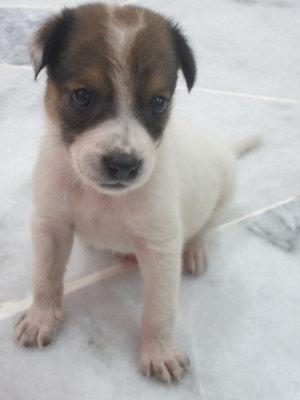

1. toy terrier - 33.02%
2. wire-haired fox terrier - 11.67%
3. Chihuahua - 4.72%
Foto: 3422e4906-2.jpg


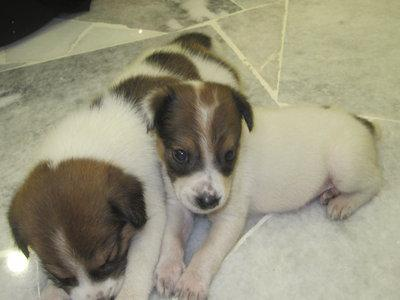

1. toy terrier - 18.65%
2. wire-haired fox terrier - 4.94%
3. Chihuahua - 4.64%
Foto: 3422e4906-3.jpg


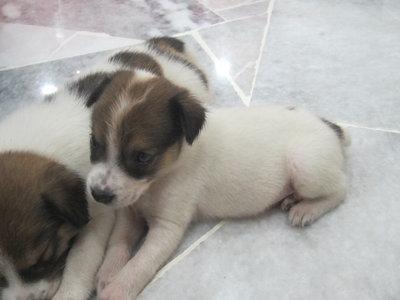

1. toy terrier - 8.14%
2. Chihuahua - 5.65%
3. wire-haired fox terrier - 3.14%
Foto: 3422e4906-4.jpg


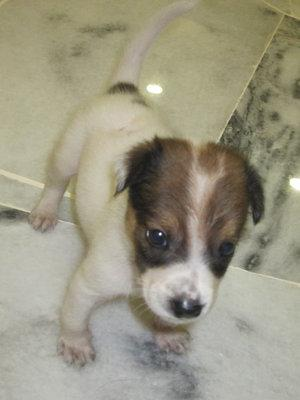

1. toy terrier - 13.00%
2. Chihuahua - 12.49%
3. wire-haired fox terrier - 6.81%
Foto: 3422e4906-5.jpg


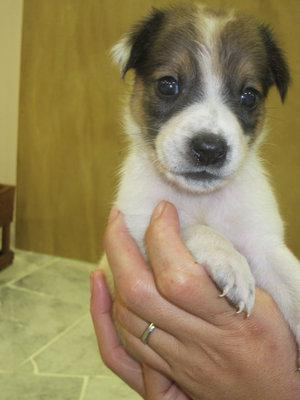

1. toy terrier - 11.83%
2. wire-haired fox terrier - 9.26%
3. Chihuahua - 4.49%
Foto: 3422e4906-6.jpg


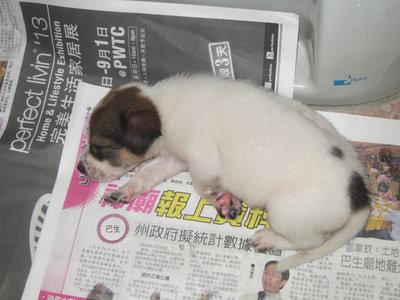

1. wire-haired fox terrier - 12.58%
2. toy terrier - 5.53%
3. Chihuahua - 4.06%
Foto: 3422e4906-7.jpg


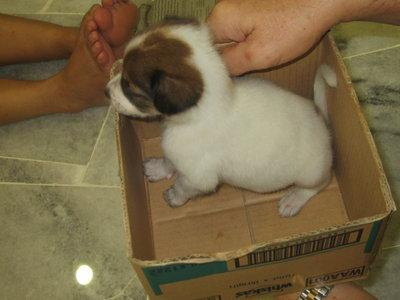

1. Sealyham terrier - 1.69%
2. Samoyed - 0.66%
3. West Highland white terrier - 0.57%


,PetID,image,rank,visual_breed,score
0,3422e4906,3422e4906-1.jpg,1,toy terrier,0.330244
1,3422e4906,3422e4906-1.jpg,2,wire-haired fox terrier,0.116730
2,3422e4906,3422e4906-1.jpg,3,Chihuahua,0.047225
3,3422e4906,3422e4906-2.jpg,1,toy terrier,0.186530
4,3422e4906,3422e4906-2.jpg,2,wire-haired fox terrier,0.049386
5,3422e4906,3422e4906-2.jpg,3,Chihuahua,0.046397
6,3422e4906,3422e4906-3.jpg,1,toy terrier,0.081407
7,3422e4906,3422e4906-3.jpg,2,Chihuahua,0.056524
8,3422e4906,3422e4906-3.jpg,3,wire-haired fox terrier,0.031385
9,3422e4906,3422e4906-4.jpg,1,toy terrier,0.130025


In [7]:
photo_level_results = []
all_photo_probs = []

for image_path in example_images:
    print("=" * 80)
    print("Foto:", image_path.name)

    image = Image.open(image_path).convert("RGB")
    display(image)

    dog_probs = predict_dog_probabilities_for_image(image_path)

    if dog_probs is None:
        print("Errore nella lettura dell'immagine.")
        continue

    all_photo_probs.append(dog_probs)

    top_predictions = top_dog_predictions_from_probs(dog_probs, top_k=3)

    for rank, pred in enumerate(top_predictions, start=1):
        print(f'{rank}. {pred["breed"]} - {pred["score"] * 100:.2f}%')

        photo_level_results.append({
            "PetID": example_pet_id,
            "image": image_path.name,
            "rank": rank,
            "visual_breed": pred["breed"],
            "score": pred["score"]
        })

photo_level_df = pd.DataFrame(photo_level_results)
photo_level_df

In [8]:
mean_probs = np.mean(all_photo_probs, axis=0)

aggregated_predictions = top_dog_predictions_from_probs(mean_probs, top_k=3)

print("RISULTATO AGGREGATO SU TUTTE LE FOTO")
print("Numero foto usate:", len(all_photo_probs))
print()

for rank, pred in enumerate(aggregated_predictions, start=1):
    print(f'{rank}. {pred["breed"]} - {pred["score"] * 100:.2f}%')

aggregated_example_df = pd.DataFrame([
    {
        "rank": rank,
        "visual_breed": pred["breed"],
        "average_score": pred["score"]
    }
    for rank, pred in enumerate(aggregated_predictions, start=1)
])

aggregated_example_df

RISULTATO AGGREGATO SU TUTTE LE FOTO
Numero foto usate: 7

1. toy terrier - 12.93%
2. wire-haired fox terrier - 6.98%
3. Chihuahua - 5.22%


,rank,visual_breed,average_score
0,1,toy terrier,0.129274
1,2,wire-haired fox terrier,0.069780
2,3,Chihuahua,0.052176


## 7. Test su pochi cani

Prima di applicare il modello a tutti i `Mixed Breed`, viene eseguita una prova sui primi 10 cani.

Se i risultati sembrano plausibili, si può eseguire la cella successiva su tutti i cani.


In [9]:
test_petids = mixed_dogs["PetID"].head(10).tolist()

test_results = []

for pet_id in tqdm(test_petids):
    row = mixed_dogs[mixed_dogs["PetID"] == pet_id].iloc[0]
    prediction = predict_visual_breeds_for_pet(pet_id)

    test_results.append({
        "PetID": pet_id,
        "Name": row["Name"],
        "PhotoAmt": row["PhotoAmt"],
        **prediction
    })

test_df = pd.DataFrame(test_results)

test_df

100%|██████████| 10/10 [00:10<00:00,  1.09s/it]


,PetID,Name,PhotoAmt,num_images_used,visual_breed_1,visual_breed_1_score,visual_breed_2,visual_breed_2_score,visual_breed_3,visual_breed_3_score
0,3422e4906,Brisco,7.0,7,toy terrier,0.129274,wire-haired fox terrier,0.069780,Chihuahua,0.052176
1,5842f1ff5,Miko,8.0,8,Rottweiler,0.030565,schipperke,0.024801,toy terrier,0.021206
2,850a43f90,Hunter,3.0,3,schipperke,0.096710,Labrador retriever,0.048065,flat-coated retriever,0.033992
3,97aa9eeac,Siu Pak & Her 6 Puppies,9.0,9,French bulldog,0.028243,Brittany spaniel,0.022413,toy terrier,0.020661
4,8b693ca84,Bear,7.0,7,toy terrier,0.097166,Italian greyhound,0.034993,wire-haired fox terrier,0.023989
5,aaedd873d,Peanut,1.0,1,Labrador retriever,0.117036,golden retriever,0.027283,standard poodle,0.013308
6,c02be41e6,Lost Dog,2.0,2,golden retriever,0.106757,Labrador retriever,0.043042,American Staffordshire terrier,0.027622
7,f9d07d5fa,Blackie,2.0,2,Norwegian elkhound,0.204912,German shepherd,0.018285,toy terrier,0.014740
8,1c92ce464,Beauty,8.0,8,Labrador retriever,0.143148,flat-coated retriever,0.074805,schipperke,0.054338
9,6436c1a59,Godiva,7.0,7,flat-coated retriever,0.014825,Chesapeake Bay retriever,0.014117,Irish setter,0.011334


## 8. Predizione su tutti i cani Mixed Breed

Questa cella può richiedere tempo perché analizza molte immagini.

Nel tuo dataset ci sono circa 5923 cani `Mixed Breed` e oltre 58.000 immagini totali.

Se vuoi prima fare una prova più piccola, cambia:

```python
mixed_to_process = mixed_dogs
```

in:

```python
mixed_to_process = mixed_dogs.head(100)
```


In [10]:
mixed_to_process = mixed_dogs

visual_results = []

for _, row in tqdm(
    mixed_to_process.iterrows(),
    total=len(mixed_to_process)
):
    pet_id = row["PetID"]

    prediction = predict_visual_breeds_for_pet(pet_id)

    visual_results.append({
        "PetID": pet_id,
        "Name": row["Name"],
        "breed1_label": row["breed1_label"],
        "breed2_label": row["breed2_label"],
        "PhotoAmt": row["PhotoAmt"],
        **prediction
    })

visual_breed_predictions = pd.DataFrame(visual_results)

visual_breed_predictions.head()

100%|██████████| 5923/5923 [4:01:42<00:00,  2.45s/it]      


,PetID,Name,breed1_label,breed2_label,PhotoAmt,num_images_used,visual_breed_1,visual_breed_1_score,visual_breed_2,visual_breed_2_score,visual_breed_3,visual_breed_3_score
0,3422e4906,Brisco,Mixed Breed,NaN,7.0,7,toy terrier,0.129274,wire-haired fox terrier,0.069780,Chihuahua,0.052176
1,5842f1ff5,Miko,Mixed Breed,NaN,8.0,8,Rottweiler,0.030565,schipperke,0.024801,toy terrier,0.021206
2,850a43f90,Hunter,Mixed Breed,NaN,3.0,3,schipperke,0.096710,Labrador retriever,0.048065,flat-coated retriever,0.033992
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,NaN,9.0,9,French bulldog,0.028243,Brittany spaniel,0.022413,toy terrier,0.020661
4,8b693ca84,Bear,Mixed Breed,NaN,7.0,7,toy terrier,0.097166,Italian greyhound,0.034993,wire-haired fox terrier,0.023989


## 9. Salvataggio CSV

Il file viene salvato in:

```text
data/results/visual_breed_predictions_mixed_breed.csv
```

Questo CSV potrà essere usato in un notebook successivo per integrare le razze visive nel sistema di matching.


In [11]:
output_file = results_dir / "visual_breed_predictions_mixed_breed.csv"

visual_breed_predictions.to_csv(
    output_file,
    index=False,
    encoding="utf-8"
)

print("File salvato in:")
print(output_file)

print("Numero righe salvate:")
print(len(visual_breed_predictions))

File salvato in:
..\data\results\visual_breed_predictions_mixed_breed.csv
Numero righe salvate:
5923


## 10. Controllo finale

Mostra i primi risultati ordinati per score della prima razza visiva.


In [12]:
visual_breed_predictions.sort_values(
    by="visual_breed_1_score",
    ascending=False
).head(20)

,PetID,Name,breed1_label,breed2_label,PhotoAmt,num_images_used,visual_breed_1,visual_breed_1_score,visual_breed_2,visual_breed_2_score,visual_breed_3,visual_breed_3_score
3337,06db81e31,Nana,Mixed Breed,Jack Russell Terrier (Parson Russell Terrier),1.0,1,Ibizan hound,0.874447,Scotch terrier,0.013600,wire-haired fox terrier,0.001441
2191,b64e30a78,Loki,Mixed Breed,NaN,1.0,1,Chihuahua,0.861752,Staffordshire bullterrier,0.016740,toy terrier,0.009443
320,dd5797b7f,6 Precious Puppies,Mixed Breed,Mixed Breed,1.0,1,Labrador retriever,0.733193,golden retriever,0.030930,American Staffordshire terrier,0.008612
5161,47d68f63c,NaN,Mixed Breed,NaN,1.0,1,Chihuahua,0.712339,toy terrier,0.015431,miniature pinscher,0.003952
626,dfff88c90,Baby,Mixed Breed,Mixed Breed,1.0,1,Ibizan hound,0.703626,Labrador retriever,0.008849,wire-haired fox terrier,0.005581
4628,191043d9c,Whittie,Mixed Breed,NaN,1.0,1,Labrador retriever,0.699942,golden retriever,0.010932,Ibizan hound,0.007654
5858,01ba86830,NaN,Mixed Breed,NaN,1.0,1,toy poodle,0.681626,miniature poodle,0.060069,standard poodle,0.006110
2617,d1f01fc04,Huggie Bear,Mixed Breed,NaN,1.0,1,Labrador retriever,0.678020,golden retriever,0.012256,beagle,0.002916
4371,a12589a09,Baby Bear,Mixed Breed,NaN,1.0,1,Labrador retriever,0.671171,golden retriever,0.020393,beagle,0.010193
3172,f2f8980cd,No Name,Mixed Breed,NaN,1.0,1,Chihuahua,0.628668,toy terrier,0.047620,miniature pinscher,0.019207


## 11. Conclusioni

Questo notebook produce una stima visiva delle razze più probabili per i cani `Mixed Breed`.

La stima considera tutte le foto disponibili per ciascun cane e aggrega i risultati tramite media delle probabilità.

Queste informazioni non sostituiscono la razza reale, ma possono essere usate come informazione ausiliaria nel sistema di matching cane–famiglia.

Nel prossimo passo si potrà integrare il file CSV prodotto nel ranking finale, assegnando un punteggio parziale quando una razza preferita dalla famiglia corrisponde a una delle razze visive stimate.
